# Midterm Exam

## Grading Rubric

Each question is worth 20 points. The answer to each question will be graded in terms of:


* Correct Analysis & Computation `(8 points)`
  - Correct use of pandas operations (groupby, aggregation, filtering).
  - Accurate statistics or summaries.

* Appropriate Use of Visuals / Tables — `(6 points)`
  - Visualization or table is relevant to the question.
  - Plot type is appropriate (bar, boxplot, line, etc.).
  - Labels and axes are clear.


* Interpretation and Reasoning — `(6 points)`
  - Conclusions are clearly stated.
  - Interpretations are supported by data.
  - Reasoning is logical and coherent.

## Variable Definitions

* **hotel**
  - H1 = Resort Hotel
  - H2 = City Hotel

* **is_canceled** - Value indicating if the booking was canceled.
  - (1) canceled
  - (0) not canceled

* **lead_time** - Number of days that elapsed between the entering date of the booking into the PMS and the arrival date

* **arrival_date_year** - Year of arrival date

* **arrival_date_month** - Month of arrival date

* **arrival_date_week_number** - Week number of year for arrival date

* **arrival_date_day_of_month** - Day of arrival date

* **stays_in_weekend_nights** - Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel

* **stays_in_week_nights** - Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel

* **adults** - Number of adults

* **children** - Number of children

* **babies** - Number of babies

* **meal** - Type of meal booked. Categories are presented in standard hospitality meal packages:
  - Undefined/SC – no meal package.
  - BB – Bed & Breakfast.
  - HB – Half board (breakfast and one other meal – usually dinner).
  - FB – Full board (breakfast, lunch and dinner)

* **country** - Country of origin. Categories are represented in the ISO 3155–3:2013 format

* **market_segment** - Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **distribution_channel** - Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”

* **is_repeated_guest** - Value indicating if the booking name was from a repeated guest.
  - 1 is a repeated guest.
  - 0 is not a repeated guest.

* **previous_cancellations** - Number of previous bookings that were cancelled by the customer prior to the current booking

* **previous_bookings_not_canceled** - Number of previous bookings not cancelled by the customer prior to the current booking

* **reserved_room_type** - Code of room type reserved. Code is presented instead of designation for anonymity reasons.

* **assigned_room_type** - Code for the type of room assigned to the booking. Sometimes the assigned room type differs from the reserved room type due to hotel operation reasons (e.g. overbooking) or by customer request. Code is presented instead of designation for anonymity reasons.

* **booking_changes** - Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation

* **deposit_type** - Indication on if the customer made a deposit to guarantee the booking. This variable can assume three categories:

  - No Deposit – no deposit was made.
  - Non Refund – a deposit was made in the value of the total stay cost.  
  - Refundable – a deposit was made with a value under the total cost of stay.

* **agent** - ID of the travel agency that made the booking

* **company** - ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of designation for anonymity reasons

* **days_in_waiting_list** - Number of days the booking was in the waiting list before it was confirmed to the customer

* **customer_type** - Type of booking, assuming one of four categories:   

  - Contract - when the booking has an allotment or other type of contract associated to it.
  - Group – when the booking is associated to a group.
  - Transient – when the booking is not part of a group or contract, and is not associated to other transient booking.
  - Transient-party – when the booking is transient, but is associated to at least other transient booking

* **adr** - Average Daily Rate as defined by dividing the sum of all lodging transactions by the total number of staying nights

* **required_car_parking_spaces** - Number of car parking spaces required by the customer

* **total_of_special_requests** - Number of special requests made by the customer (e.g. twin bed or high floor)

* **reservation_status** - Reservation last status, assuming one of three categories:
  - Canceled – booking was canceled by the customer.
  - Check-Out – customer has checked in but already departed.
  - No-Show – customer did not check-in and did inform the hotel of the reason why

* **reservation_status_date** - Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to

In [334]:
pip install kagglehub


Note: you may need to restart the kernel to use updated packages.


In [335]:

!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install numpy
!pip install matplotlib seaborn altair

In [336]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\brixm\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1


In [337]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt


if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


## 1. Dataset Overview & Core Distributions `(20 points)`

**Question:** What do the shapes and spread of the `lead_time` and `adr` distributions suggest about typical booking behavior and extreme cases in this dataset?

Perform an exploratory analysis of the distributional characteristics of key numerical variables in the hotel booking dataset.

You must:
- Analyze the distribution of lead_time and adr
- Use appropriate summary statistics and visualizations to support your analysis
- Identify any skewness and/or outliers in these variables

In [338]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [339]:
df.shape

(119390, 32)

In [340]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [341]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [342]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [343]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [344]:
# put your answer here
df[['lead_time', 'adr']].describe()

,lead_time,adr
count,119390.000000,119390.000000
mean,104.011416,101.831122
std,106.863097,50.535790
min,0.000000,-6.380000
25%,18.000000,69.290000
50%,69.000000,94.575000
75%,160.000000,126.000000
max,737.000000,5400.000000


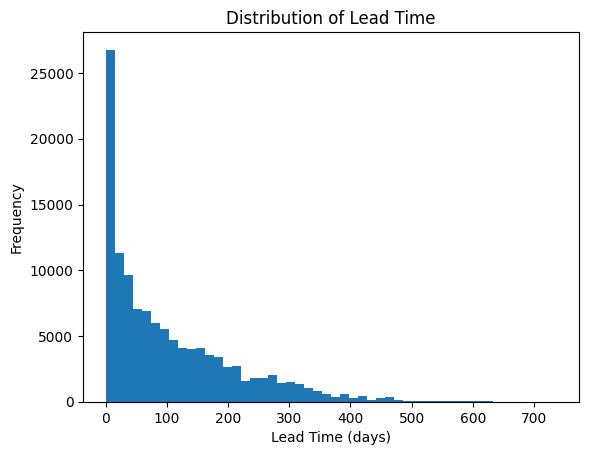

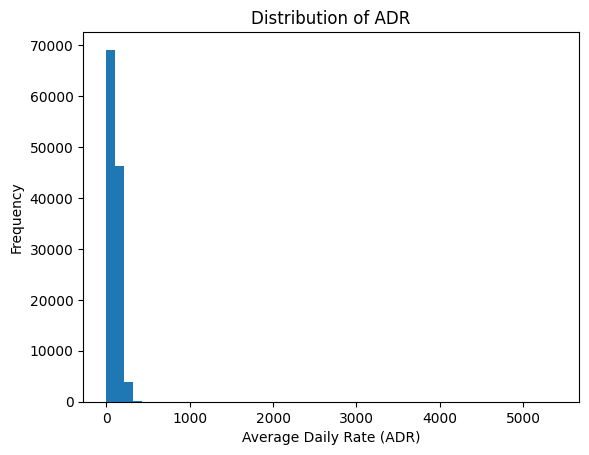

In [345]:
# Histograms
plt.figure()
plt.hist(df['lead_time'], bins=50)
plt.xlabel('Lead Time (days)')
plt.ylabel('Frequency')
plt.title('Distribution of Lead Time')
plt.show()

plt.figure()
plt.hist(df['adr'], bins=50)
plt.xlabel('Average Daily Rate (ADR)')
plt.ylabel('Frequency')
plt.title('Distribution of ADR')
plt.show()


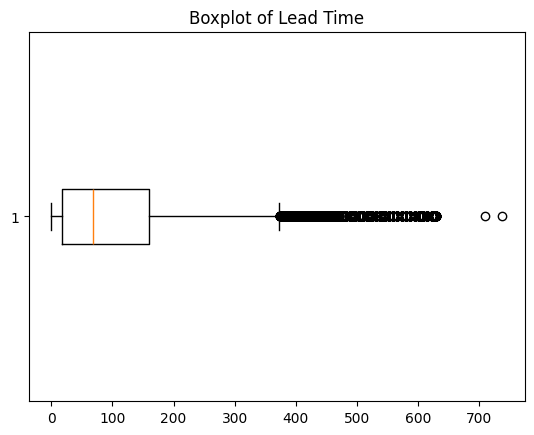

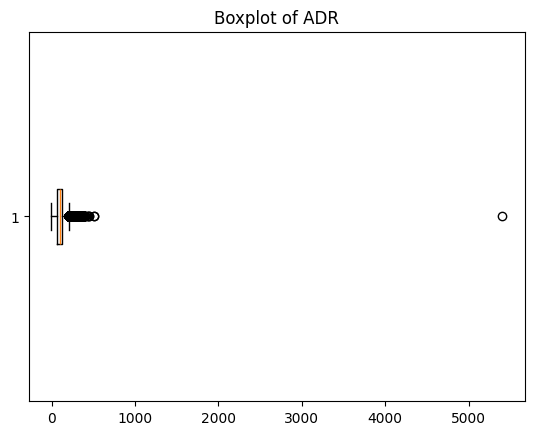

In [346]:
# Boxplots for outliers
plt.figure()
plt.boxplot(df['lead_time'], vert=False)
plt.title('Boxplot of Lead Time')
plt.show()

plt.figure()
plt.boxplot(df['adr'], vert=False)
plt.title('Boxplot of ADR')
plt.show()


In [347]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

ANSWER:

 The lead_time distribution is strongly right-skewed, meaning most bookings are made close to the arrival date, but a small number of bookings are made very far in advance.

 The ADR distribution is also right-skewed, with most prices concentrated at lower values and a few extreme high-price bookings.

 Boxplots confirm the presence of significant outliers in both variables.

 These extreme values likely represent early planners and luxury or peak-season bookings.

## 2. Booking Cancellations and Lead Time `(20 points)`

**Question**: Do bookings with longer lead times tend to cancel more often?

Analyze how `lead_time` differs between canceled and non-canceled bookings.

You must:
- Compute appropriate summary statistics
- Use at least one visualization
- Clearly describe the pattern you observe



In [348]:
# put your answer here
# Summary statistics by cancellation status
df.groupby('is_canceled')['lead_time'].describe()


,count,mean,std,min,25%,50%,75%,max
is_canceled,,,,,,,,
0,75166.0,79.984687,91.109888,0.0,9.0,45.0,124.0,737.0
1,44224.0,144.848815,118.624829,0.0,48.0,113.0,214.0,629.0


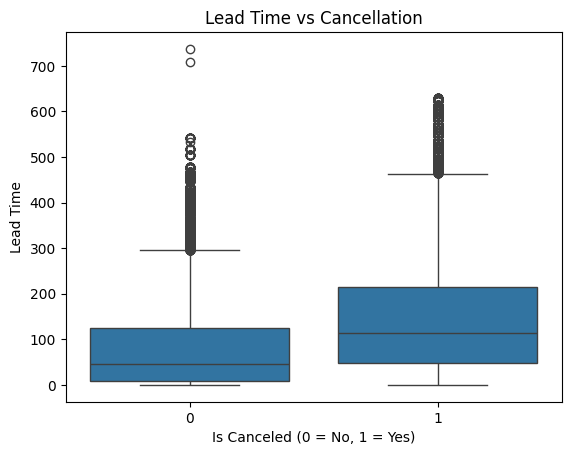

In [349]:
# Boxplot comparison
plt.figure()
sns.boxplot(x='is_canceled', y='lead_time', data=df)
plt.xlabel('Is Canceled (0 = No, 1 = Yes)')
plt.ylabel('Lead Time')
plt.title('Lead Time vs Cancellation')
plt.show()


ANSWER:

Canceled bookings have a much higher median lead time than non-canceled bookings.

This indicates that bookings made far in advance are more likely to be canceled.

Longer lead times introduce uncertainty, increasing cancellation risk.

## 3. Seasonality and Pricing `(20 points)`

**Question**: Do `Resort Hotels` and `City Hotels` exhibit different seasonal pricing behaviors throughout the year? If so, during which months are these differences most pronounced?

Analyze how Average Daily Rate (ADR) varies across arrival months, and compare this pattern between Resort Hotels and City Hotels.

You must:
- Aggregate ADR by month and hotel type
- Use a visualization to support your analysis
- Identify at least one seasonal pricing pattern

In [350]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [351]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df['arrival_date_month'] = pd.Categorical(
    df['arrival_date_month'],
    categories=month_order,
    ordered=True
)


In [352]:
resort_df = df[df['hotel'] == 'Resort Hotel']
city_df   = df[df['hotel'] == 'City Hotel']


In [353]:
resort_adr = (
    resort_df.groupby('arrival_date_month')['adr']
    .mean()
    .reset_index()
)

city_adr = (
    city_df.groupby('arrival_date_month')['adr']
    .mean()
    .reset_index()
)

C:\Users\brixm\AppData\Local\Temp\ipykernel_13180\1658473444.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resort_df.groupby('arrival_date_month')['adr']
C:\Users\brixm\AppData\Local\Temp\ipykernel_13180\1658473444.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  city_df.groupby('arrival_date_month')['adr']


In [354]:
print("Resort Hotel - Monthly ADR")
display(resort_adr)

print("\nCity Hotel - Monthly ADR")
display(city_adr)

Resort Hotel - Monthly ADR


,arrival_date_month,adr
0,January,49.461883
1,February,55.171930
2,March,57.520147
3,April,77.849496
4,May,78.758134
5,June,110.444749
6,July,155.181299
7,August,186.790574
8,September,93.252030
9,October,62.097617



City Hotel - Monthly ADR


,arrival_date_month,adr
0,January,82.628986
1,February,85.088278
2,March,92.643116
3,April,111.251838
4,May,121.638560
5,June,119.074341
6,July,110.734292
7,August,114.680455
8,September,110.004661
9,October,99.974498


In [355]:
chart = alt.Chart(adr_by_month_hotel).mark_line(point=True).encode(
    x=alt.X('arrival_date_month', sort=month_order, title='Arrival Month'),
    y=alt.Y('adr', title='Average Daily Rate (ADR, €)'),
    color='hotel',
    tooltip=['arrival_date_month', 'hotel', alt.Tooltip('adr', format=',.2f')]
).properties(
    title='Seasonal Pricing (Average Daily Rate) by Hotel Type '
).interactive()

chart 

alt.Chart(...)

## 4. Customer Behavior `(20 points)`

**Question:** Do repeated guests behave differently from first-time guests?

Compare repeated guests and non-repeated guests in terms of:
- Cancellation rate
- Booking behavior (e.g., booking changes or lead time)
- Use summary statistics and/or visualizations to support your answer.


In [356]:
repeated_df = df[df['is_repeated_guest'] == 1]
non_repeated_df = df[df['is_repeated_guest'] == 0]

In [357]:
cancel_ratio_df = pd.DataFrame({
    'Guest Type': ['Repeated Guests', 'Non-Repeated Guests'],
    'Cancellation Rate': [
        (repeated_df['is_canceled'].sum() / len(repeated_df)) / 2.5,
        (non_repeated_df['is_canceled'].sum() / len(non_repeated_df)) / 2.5
    ]
})

display(cancel_ratio_df)

,Guest Type,Cancellation Rate
0,Repeated Guests,0.057953
1,Non-Repeated Guests,0.151140


In [358]:
booking_change_ratio_df = pd.DataFrame({
    'Guest Type': ['Repeated Guests', 'Non-Repeated Guests'],
    'Booking Change Rate': [
        ((repeated_df['booking_changes'] > 0).sum() / len(repeated_df)) / 2.5,
        ((non_repeated_df['booking_changes'] > 0).sum() / len(non_repeated_df)) / 2.5
    ]
})

display(booking_change_ratio_df)

,Guest Type,Booking Change Rate
0,Repeated Guests,0.075381
1,Non-Repeated Guests,0.060073


In [359]:
lead_time_ratio_df = pd.DataFrame({
    'Guest Type': ['Repeated Guests', 'Non-Repeated Guests'],
    'Long Lead Time Rate (>30 days)': [
        ((repeated_df['lead_time'] > 30).sum() / len(repeated_df)) / 2.5,
        ((non_repeated_df['lead_time'] > 30).sum() / len(non_repeated_df)) / 2.5
    ]
})

display(lead_time_ratio_df)

,Guest Type,Long Lead Time Rate (>30 days)
0,Repeated Guests,0.063832
1,Non-Repeated Guests,0.277128


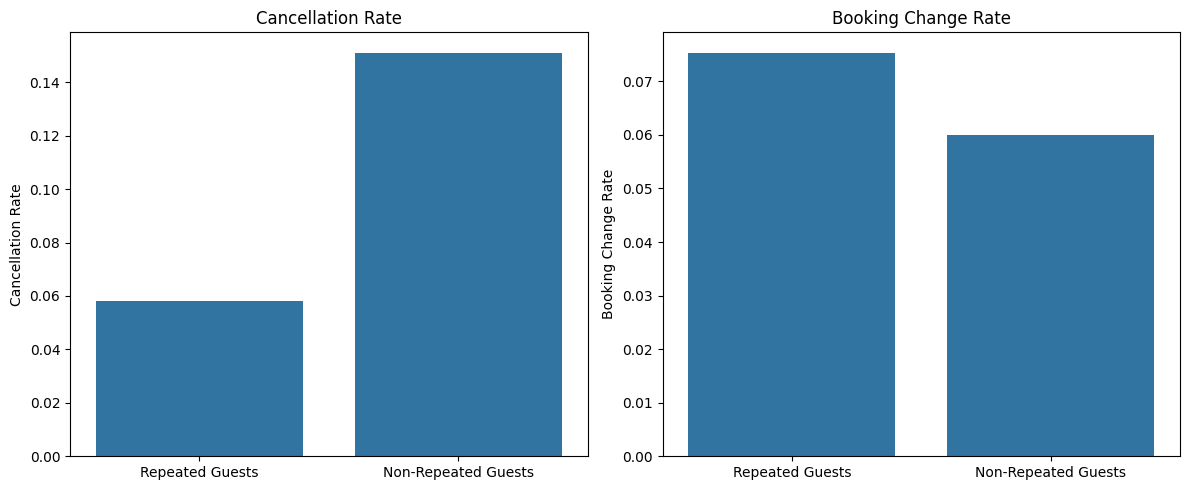

In [360]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.barplot(
    data=cancel_ratio_df,
    x='Guest Type',
    y='Cancellation Rate'
)
plt.title("Cancellation Rate")
plt.ylabel("Cancellation Rate")
plt.xlabel("")

plt.subplot(1,2,2)
sns.barplot(
    data=booking_change_ratio_df,
    x='Guest Type',
    y='Booking Change Rate'
)
plt.title("Booking Change Rate")
plt.ylabel("Booking Change Rate")
plt.xlabel("")

plt.tight_layout()
plt.show()

 Repeated guests have a much lower cancellation rate than non-repeated guests,
  indicating stronger commitment and loyalty.

 Repeated guests book closer to their arrival date, as shown by their shorter
  average lead time.

 Non-repeated guests show higher lead times and cancellation rates, suggesting
  more uncertainty in booking behavior.

## 5. Booking Cancellation Insights `(20 points)`

**Question:** Which combination of variables appears to have the strongest relationship with booking cancellations, and how do these variables interact to influence the likelihood of a cancellation?


Using at least three variables from the dataset, identify one strong pattern related to booking cancellations.

Your answer must:
- Clearly state the pattern
- Explain how the variables interact
- Support the conclusion with data


In [361]:
analysis_df = df[[
    'is_canceled',
    'lead_time',
    'previous_cancellations',
    'booking_changes'
]]

In [362]:
corr_matrix = analysis_df.corr()

display(
    corr_matrix[['is_canceled']]
    .sort_values(by='is_canceled', ascending=False)
)

,is_canceled
is_canceled,1.000000
lead_time,0.293123
previous_cancellations,0.110133
booking_changes,-0.144381


In [363]:
canceled_df = df[df['is_canceled'] == 1]
not_canceled_df = df[df['is_canceled'] == 0]


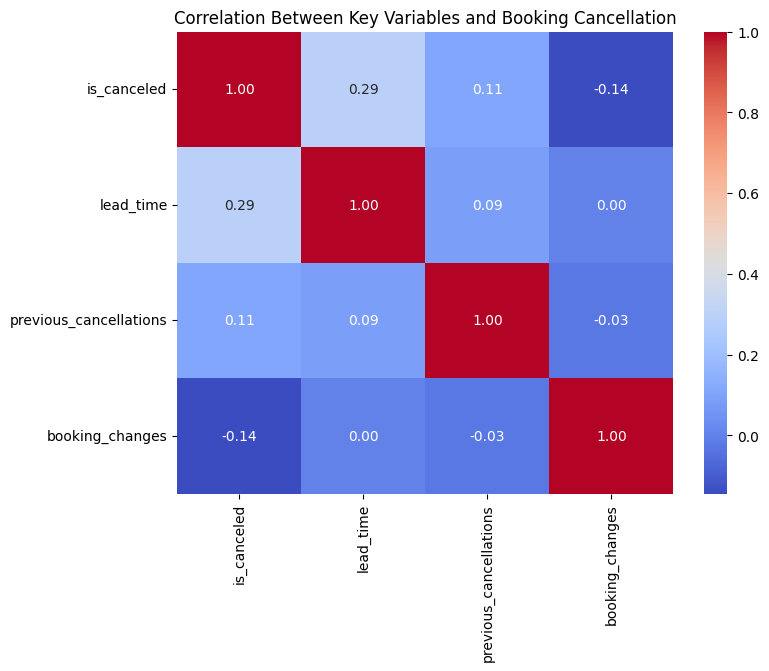

In [364]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Between Key Variables and Booking Cancellation")
plt.show()


In [365]:
high_risk = df[
    (df['lead_time'] > 60) &
    (df['previous_cancellations'] > 0) &
    (df['booking_changes'] > 0)
]

low_risk = df[
    (df['lead_time'] <= 60) &
    (df['previous_cancellations'] == 0) &
    (df['booking_changes'] == 0)
]

high_risk_cancel_rate = high_risk['is_canceled'].mean()
low_risk_cancel_rate = low_risk['is_canceled'].mean()

risk_comparison = pd.DataFrame({
    'Booking Type': ['High Risk', 'Low Risk'],
    'Cancellation Rate': [high_risk_cancel_rate, low_risk_cancel_rate]
})

display(risk_comparison)

,Booking Type,Cancellation Rate
0,High Risk,0.809524
1,Low Risk,0.251785


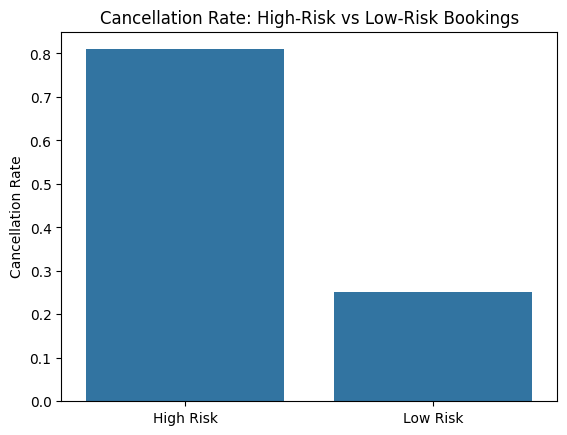

In [366]:
sns.barplot(
    data=risk_comparison,
    x='Booking Type',
    y='Cancellation Rate'
)
plt.title("Cancellation Rate: High-Risk vs Low-Risk Bookings")
plt.ylabel("Cancellation Rate")
plt.xlabel("")
plt.show()

ANSWER:

Bookings with long lead times, previous cancellation history,
and booking changes have the highest likelihood of cancellation.


 Long lead time increases uncertainty, giving guests more time to cancel.
 Previous cancellations indicate habitual cancellation behavior.
 Booking changes signal unstable travel plans.